# Test YOLOv1 COCO trên ảnh chưa train

Notebook này tự chọn một ảnh COCO không nằm trong `MAX_TRAIN_IMAGES` đầu tiên mà bạn đã dùng để overfit/debug.

In [15]:
import json, random
from pathlib import Path

import torch
import torchvision.transforms as transforms
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

from model import Yolov1
from utils import cellboxes_to_boxes, non_max_suppression

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_CLASSES = 80

CHECKPOINT_PATH = Path("coco_overfit.pth.tar")
ANNOTATION_FILE = Path("coco_raw/annotations/instances_val2017.json")
IMG_DIR = Path("coco_raw/val2017")

MAX_TRAIN_IMAGES = 8
CONF_THRESHOLD = 0.25
IOU_THRESHOLD = 0.5
USE_TRAIN_MODE = True  # nên dùng khi checkpoint overfit rất ít ảnh với BatchNorm

# Nếu muốn test ảnh ngoài COCO, sửa thành Path("duong_dan_anh.jpg").
IMAGE_PATH = None

print("Device:", DEVICE)

Device: cpu


In [16]:
with open(ANNOTATION_FILE, "r") as f:
    coco = json.load(f)

class_names = [category["name"] for category in coco["categories"]]

# Train hiện tại dùng remove_empty=True rồi lấy MAX_TRAIN_IMAGES ảnh đầu tiên.
image_ids_with_box = {
    ann["image_id"]
    for ann in coco["annotations"]
    if ann.get("iscrowd", 0) == 0 and ann["bbox"][2] > 0 and ann["bbox"][3] > 0
}
images_with_box = [img for img in coco["images"] if img["id"] in image_ids_with_box]
seen_files = {img["file_name"] for img in images_with_box[:MAX_TRAIN_IMAGES]}

if IMAGE_PATH is None:
    unseen_images = [img for img in images_with_box[MAX_TRAIN_IMAGES:] if (IMG_DIR / img["file_name"]).exists()]
    image_info = random.choice(unseen_images)
    image_path = IMG_DIR / image_info["file_name"]
else:
    image_path = Path(IMAGE_PATH)

print("Seen train/debug images:", sorted(seen_files))
print("Test image:", image_path)
print("Is seen image?", image_path.name in seen_files)

Seen train/debug images: ['000000006818.jpg', '000000037777.jpg', '000000087038.jpg', '000000174482.jpg', '000000252219.jpg', '000000397133.jpg', '000000403385.jpg', '000000480985.jpg']
Test image: coco_raw/val2017/000000261888.jpg
Is seen image? False


In [17]:
model = Yolov1(split_size=7, num_boxes=2, num_classes=NUM_CLASSES).to(DEVICE)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

if "state_dict" in checkpoint:
    model.load_state_dict(checkpoint["state_dict"])
else:
    model.load_state_dict(checkpoint)

if USE_TRAIN_MODE:
    model.train()
else:
    model.eval()

print("Loaded checkpoint:", CHECKPOINT_PATH)

Loaded checkpoint: coco_overfit.pth.tar


In [18]:
image = Image.open(image_path).convert("RGB")
transform = transforms.Compose([transforms.Resize((448, 448)), transforms.ToTensor()])
x = transform(image).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    predictions = model(x)

boxes = cellboxes_to_boxes(predictions, C=NUM_CLASSES)[0]
boxes = non_max_suppression(
    boxes,
    iou_threshold=IOU_THRESHOLD,
    threshold=CONF_THRESHOLD,
    box_format="midpoint",
)

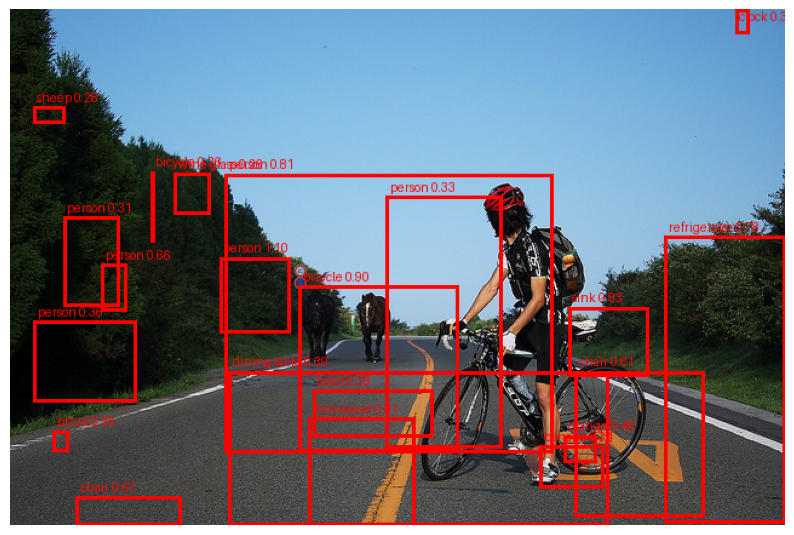

In [19]:
result = image.copy()
draw = ImageDraw.Draw(result)
img_w, img_h = result.size

for class_id, score, x_mid, y_mid, box_w, box_h in boxes:
    x1 = max(0, (x_mid - box_w / 2) * img_w)
    y1 = max(0, (y_mid - box_h / 2) * img_h)
    x2 = min(img_w, (x_mid + box_w / 2) * img_w)
    y2 = min(img_h, (y_mid + box_h / 2) * img_h)

    label = f"{class_names[int(class_id)]} {score:.2f}"
    draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
    draw.text((x1 + 3, max(0, y1 - 14)), label, fill="red")

plt.figure(figsize=(10, 10))
plt.imshow(result)
plt.axis("off")
plt.show()